# Example: Get financial and non-financial stock data

In [1]:
import json

import pandas as pd
import requests
from pandas.io.json import json_normalize


def getdata(stock):
    # Company Quote Group of Items
    company_quote = requests.get(
        f"https://financialmodelingprep.com/api/v3/quote/{stock}"
    )
    company_quote = company_quote.json()
    share_price = float("{0:.2f}".format(company_quote[0]["price"]))

    # Balance Sheet Group of Items
    BS = requests.get(
        f"https://financialmodelingprep.com/api/v3/financials/balance-sheet-statement/{stock}?period=quarter"
    )
    BS = BS.json()

    # Total Cash
    cash = float(
        "{0:.2f}".format(
            float(BS["financials"][0]["Cash and short-term investments"]) / 10**9
        )
    )
    # Total Debt
    debt = float("{0:.2f}".format(float(BS["financials"][0]["Total debt"]) / 10**9))

    # Income Statement Group of Items
    IS = requests.get(
        f"https://financialmodelingprep.com/api/v3/financials/income-statement/{stock}?period=quarter"
    )
    IS = IS.json()

    # Most Recent Quarterly Revenue
    qRev = float("{0:.2f}".format(float(IS["financials"][0]["Revenue"]) / 10**9))

    # Company Profile Group of Items
    company_info = requests.get(
        f"https://financialmodelingprep.com/api/v3/company/profile/{stock}"
    )
    company_info = company_info.json()

    # Chief Executive Officer
    ceo = company_info["profile"]["ceo"]

    return (share_price, cash, debt, qRev, ceo)


tickers = (
    "AAPL",
    "MSFT",
    "GOOG",
    "T",
    "CSCO",
    "INTC",
    "ORCL",
    "AMZN",
    "FB",
    "TSLA",
    "NVDA",
)

data = map(getdata, tickers)

df = pd.DataFrame(
    data,
    columns=["Share Price", "Total Cash", "Total Debt", "Q3 2019 Revenue", "CEO"],
    index=tickers,
)

print(df)

writer = pd.ExcelWriter("example.xlsx")
df.to_excel(writer, "Statistics")
writer.save()

      Share Price  Total Cash  Total Debt  Q3 2019 Revenue  \
AAPL       287.63      107.16      103.30            91.82   
MSFT       174.14      134.25       69.61            36.91   
GOOG      1327.61      119.67        4.91            46.08   
T           31.28       12.13      163.15            46.82   
CSCO        43.15       28.04       18.50            13.16   
INTC        60.09       12.68       39.92            19.83   
ORCL        53.78       25.86       51.67             9.80   
AMZN      2350.48       55.02       24.72            87.44   
FB         194.31       54.85       10.32            21.08   
TSLA       788.00        6.27        2.16             7.38   
NVDA       297.50        9.77        0.56             3.01   

                                CEO  
AAPL                Timothy D. Cook  
MSFT                  Satya Nadella  
GOOG                     Larry Page  
T             Randall L. Stephenson  
CSCO                Charles Robbins  
INTC              Brian M. 

# Example of time series with RDS-A

Let's explore the RDS-A stock ticker. 

In [168]:
# getting historical data for RDS-A. This code calls the API and transforms the result into a DataFrame.

ticker = "RDS-A"
target = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}"
rds = pd.read_json(target)
rds = json_normalize(rds["historical"])
rds["date"] = pd.to_datetime(rds["date"])
rds.set_index("date", inplace=True)

In [169]:
rds.head()

,open,high,low,close,adjClose,volume,unadjustedVolume,change,changePercent,vwap,label,changeOverTime
date,,,,,,,,,,,,
2019-04-25,63.63,63.94,63.49,63.62,59.61,2044000.0,2044000.0,-0.01,-0.016,63.68333,"April 25, 19",-0.00016
2019-04-26,63.33,63.33,62.64,63.06,59.08,2914000.0,2914000.0,-0.27,-0.426,63.01000,"April 26, 19",-0.00426
2019-04-29,62.73,63.17,62.59,63.13,59.15,1532400.0,1532400.0,0.40,0.638,62.96333,"April 29, 19",0.00638
2019-04-30,63.70,63.82,63.37,63.53,59.52,2673000.0,2673000.0,-0.17,-0.267,63.57333,"April 30, 19",-0.00267
2019-05-01,63.50,63.51,62.70,62.72,58.76,2342400.0,2342400.0,-0.78,-1.228,62.97667,"May 01, 19",-0.01228


# Bollinger Bands

A basic method of analysis for stocks is the Bollinger band. This uses the moving average and the moving standard deviation to identify points where the trader should buy/sell. We start by defining how the Bollinger Bands are calculated and defining how we want the data to be plotted. These defined functions can be used again for analizing another stock. 

In [176]:
def bollinger_bands(
    df: pd.DataFrame = df, target_col: str = "adjClose"
) -> pd.DataFrame:
    """Calculates Bollinger Bands and returns an updated DataFrame.

    :param df: DataFrame
    :param target_col: column that will be used for the calcuations
    :type target_col: str

    :return: df with additional columns
    :rtype: pd.DataFrame
    """

    df["20 Day MA"] = df[target_col].rolling(20).mean()
    df["20 Day MA_lower bound"] = df["20 Day MA"] - df[target_col].rolling(20).std() * 2
    df["20 Day MA_upper bound"] = df["20 Day MA"] + df[target_col].rolling(20).std() * 2

    return df


def bb_plot(df: pd.DataFrame = df, target_col: str = "adjClose") -> plt:
    """Calculates time series plot with Bollinger Bands

    :param df: DataFrame
    :param target_col: column that will be used for the calcuations
    :type target_col: str

    :return: plot
    :rtype: matplotlib.pyplot
    """

    x = df.index
    y = df[["adjClose", "20 Day MA", "20 Day MA_lower bound", "20 Day MA_upper bound"]]

    plt.fill_between(
        x, rds["20 Day MA_lower bound"], rds["20 Day MA_upper bound"], alpha=0.5
    )
    plt.plot(x, y)
    plt.title(f"Bollinger Bands for {ticker}")
    plt.xlabel("Date (Year/Month)")
    plt.ylabel("Price(USD)")
    plt.legend(y)
    plt.show()

    return plt

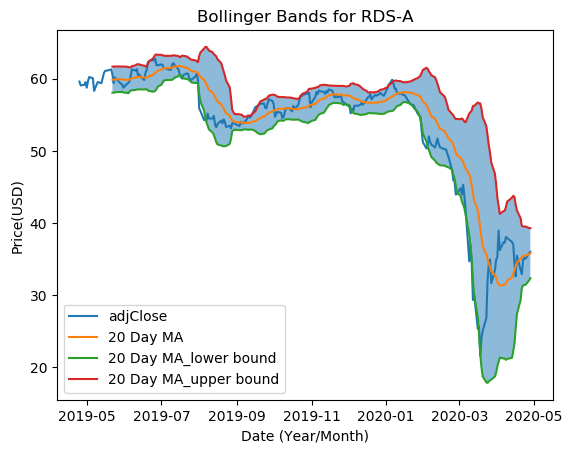

<module 'matplotlib.pyplot' from '/opt/anaconda3/lib/python3.7/site-packages/matplotlib/pyplot.py'>

In [177]:
rds = bollinger_bands(rds, "adjClose")
bb_plot(rds)

# Bollinger Band Strategy

The basic strategy is to buy/sell short if the actual value moves beyond the bands. The assumption is that the stock will return toward the mean. 

Let's test our returns if we follow this strategy. 

In [178]:
import numpy as np

df = rds


def bb_strategy(df: pd.DataFrame) -> pd.DataFrame:
    df["Position"] = None
    # Fill our newly created position column - set to sell (-1) when the price hits the upper band, and set to buy (1) when it hits the lower band
    for row in range(len(df)):
        if (df["adjClose"].iloc[row] > df["20 Day MA_upper bound"].iloc[row]) and (
            df["adjClose"].iloc[row - 1] < df["20 Day MA_upper bound"].iloc[row - 1]
        ):
            df["Position"].iloc[row] = -1

        if (df["adjClose"].iloc[row] < df["20 Day MA_lower bound"].iloc[row]) and (
            df["adjClose"].iloc[row - 1] > df["20 Day MA_lower bound"].iloc[row - 1]
        ):
            df["Position"].iloc[row] = 1

    # Forward fill our position column to replace the "None" values with the correct long/short positions to represent the "holding" of our position
    # forward through time
    df["Position"].fillna(method="ffill", inplace=True)

    # Calculate the daily market return and multiply that by the position to determine strategy returns
    df["Market Return"] = np.log(df["adjClose"] / df["adjClose"].shift(1))
    df["Strategy Return"] = df["Market Return"] * df["Position"]

    return df

In [166]:
df = bb_strategy(df)

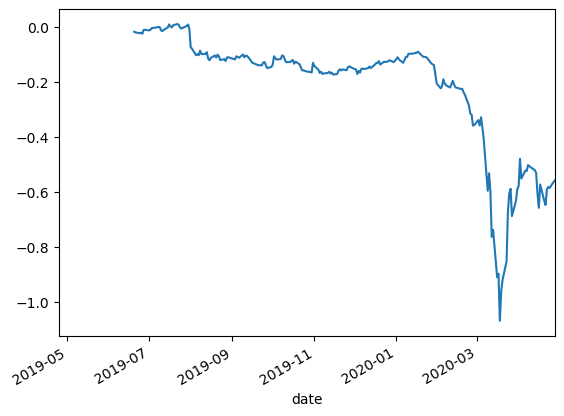

In [167]:
df["Strategy Return"].cumsum().plot()

In [132]:
# Monte Carlo valuation of European call option
# in Black-Scholes-Merton model
# bsm_mcs_euro.py
#
import numpy as np

# Parameter Values
S0 = rds["adjClose"][-1]  # initial index level
K = 35.0  # strike price
T = 1  # time-to-maturity
r = 0.05  # riskless short rate
sigma = np.std(rds["changeOverTime"])  # standard deviation of the percent change
I = 100000  # number of simulations
# Valuation Algorithm
z = np.random.standard_normal(I)  # pseudorandom numbers

ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
# index values at maturity
hT = np.maximum(ST - K, 0)  # inner values at maturity
C0 = np.exp(-r * T) * np.sum(hT) / I  # Monte Carlo estimator
# Result Output
print(f"Value of the Call Option {C0:.5f}")

Value of the Call Option 2.70675


In [130]:
rds["changeOverTime_log"] = np.log(rds["changeOverTime"])

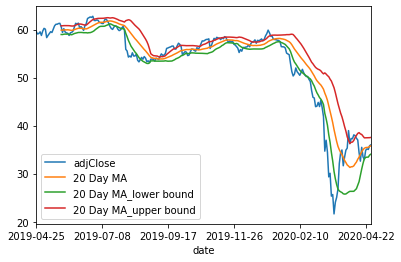

In [68]:
# version 1 using Pandas for the plot
rds[["adjClose", "20 Day MA", "20 Day MA_lower bound", "20 Day MA_upper bound"]].plot()

In [125]:
len(ST)

100000

No handles with labels found to put in legend.


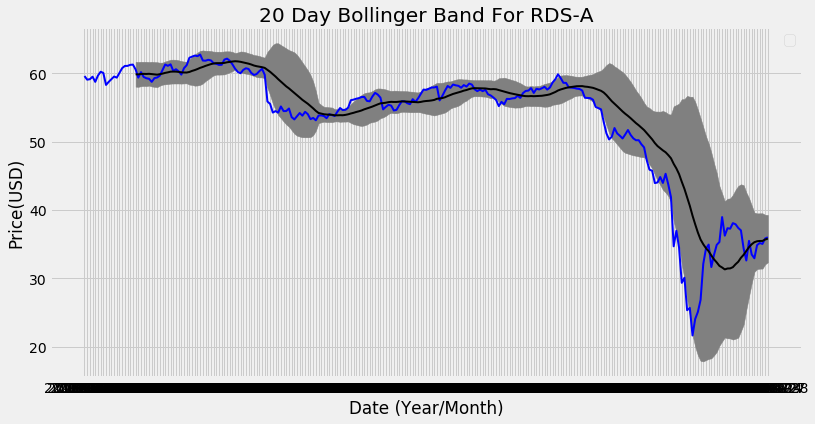

In [92]:
# set style, empty figure and axes
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Get index values for the X axis
x_axis = rds.index

# Plot shaded 20 Day Bollinger Band
ax.fill_between(
    x_axis, rds["20 Day MA_lower bound"], rds["20 Day MA_upper bound"], color="grey"
)

# Plot Adjust Closing Price and Moving Averages
ax.plot(x_axis, rds["adjClose"], color="blue", lw=2)
ax.plot(x_axis, rds["20 Day MA"], color="black", lw=2)

# Set Title & Show the Image
ax.set_title("20 Day Bollinger Band For RDS-A")
ax.set_xlabel("Date (Year/Month)")
ax.set_ylabel("Price(USD)")
ax.legend()
plt.show()